# Exemplo 3 - Problema de Corte de Estoque


# 1. Configuração do Ambiente

Nesta etapa, configuramos o ambiente do Google Colab para utilizar a linguagem de otimização **CMPL**.

Essa célula deve ser executada apenas:
- Ao abrir o notebook pela primeira vez
- Ou quando o ambiente for reiniciado/desconectado

O que será feito:
- Download do COLIOP/CMPL (disponível em [coliop.org](https://www.coliop.org/download.html))
- Extração dos arquivos
- Configuração de variáveis de ambiente
- Inclusão das bibliotecas no Python

In [1]:
### Esta célula dever ser executada apenas quando o notebook for aberto
### ou quando o ambiente for desconectado e for necessário reconectá-lo
### por inatividade!

# Importação de bibliotecas do sistema
import os, sys

# Baixa o pacote do CMPL a partir do site oficial
os.system("wget https://www.coliop.org/_download/Cmpl-2-1-0-linux64.tar.gz")

# Extrai o arquivo baixado
os.system("tar -xzf Cmpl-2-1-0-linux64.tar.gz")

# Define o diretório principal do CMPL
os.environ["CMPLHOME"] = "/content/Cmpl-2-1-0-linux64"

# Adiciona o executável do CMPL ao PATH do sistema
os.environ["PATH"] += ":/content/Cmpl-2-1-0-linux64/bin"

# Configura bibliotecas compartilhadas necessárias
os.environ["LD_LIBRARY_PATH"] = "/content/Cmpl-2-1-0-linux64/bin/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

# Adiciona os módulos Python do CMPL ao caminho de importação
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/lib3")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/scripts/Unix")

# 2. Definição do Modelo de Otimização

Aqui definimos um problema de **programação linear inteira** usando a linguagem do CMPL.

## 2.1 Objetivo:
Minimizar a perda total em metros de madeira.

## 2.2 Elementos do modelo:
- **I**: Conjunto de padrões de corte.
- **J**: Conjunto de tábuas demandadas.
- **Perda**: Perda residual em metros de cada padrão de corte.
- **Produção**: Quantidade ofertada pelas plantas de produção.
- **Demanda**: Quantidade demandada de cada tábua.

## 2.3 Variável de decisão:
- `x[i]`: quantidade de tábuas cortadas no padrão `i`.

In [2]:
# Definição do modelo combinado (dados e generalização) em linguagem CMPL (como string)
codigo_cmpl = """
par:
    # Conjuntos
    J := set(1..3);  # 1: 1.5m, 2: 2.5m, 3: 3.5m
    I := set(1..6);  # Padrões de corte não-dominados

    # Demandas de cada peça
    D[J] := (200, 250, 130);

    # Perda residual (em metros) de cada padrão de corte j
    PERDA[I] := (1.0, 0.0, 0.5, 0.5, 1.0, 0.0);

    # Matriz de rendimento PRODUCAO[i, j] (Quantidade de peças de tamanho i no padrão j)
    PRODUCAO[J, I] := (
        (4, 3, 2, 1, 0, 0),  # Peças de 1.5m geradas em cada padrão
        (0, 1, 0, 2, 1, 0),  # Peças de 2.5m geradas em cada padrão
        (0, 0, 1, 0, 1, 2)   # Peças de 3.5m geradas em cada padrão
    );

var:
    # Variáveis de decisão inteiras e não-negativas
    x[I] : integer[0..];

obj:
    # Função objetivo: Minimizar a perda total de madeira
    perda_total: sum{i in I: PERDA[i]*x[i]} -> min;

con:
    # Restrição: A produção de cada tamanho de tábua deve cobrir a demanda
    AtenderDemanda{j in J: sum{i in I: PRODUCAO[j,i] * x[i]} >= D[j];}

"""

# Salva o modelo em um arquivo .cmpl
with open("/content/Exemplo-3_cutting_to_stock_problem.cmpl", "w") as f:
    f.write(codigo_cmpl)

# 3. Resolução do Modelo

Nesta etapa utilizamos a **API Python pyCmpl** para fazer a integração entre modelo e resolvedor:
1. Carregamos o modelo criado
2. Executamos o solver
3. Exibimos o relatório da solução
4. Tratamento de erro para capturar possíveis problemas.

Também é possível fazer a entrada de dados por um arquivo python, atribuindo valores para conjuntos e parâmetros do modelo, utilizando atributos e métodos do pyCmpl. Isto será objeto para outra aula.

In [4]:
# Importa a biblioteca do CMPL para Python
from pyCmpl import *

try:
    # Cria o objeto do modelo a partir do arquivo
    modelo = Cmpl("/content/Exemplo-3_cutting_to_stock_problem.cmpl")

    # Resolve o problema de otimização
    modelo.solve()

    # Exibe o relatório da solução (valores ótimos)
    modelo.solutionReport()

except CmplException as e:
    # Caso ocorra erro, exibe a mensagem
    print(e.msg)

---------------------------------------------------------------------------------------------------------
Problem              Exemplo-3_cutting_to_stock_problem.cmpl
Nr. of variables     6
Nr. of constraints   3
Objective name       perda_total
Solver name          HIGHS
Display variables    (all)
Display constraints  (all)
---------------------------------------------------------------------------------------------------------

Objective status     INTEGER OPTIMAL
Objective value      0.00                (min!)

Variables           
Name                 Type            Activity          LowerBound          UpperBound            Marginal
---------------------------------------------------------------------------------------------------------
x[1]                    I                   0                0.00                 inf                   -
x[2]                    I                 250                0.00                 inf                   -
x[3]                    I          

In [5]:
#@title Função para visualização de dados

import re
import numpy as np
import matplotlib.pyplot as plt


def extrair_producao(codigo_cmpl):
    """
    Extrai a matriz PRODUCAO diretamente
    do código CMPL utilizado no modelo.
    """

    padrao = r"PRODUCAO\[J,\s*I\]\s*:=\s*\((.*?)\);"

    resultado = re.search(
        padrao,
        codigo_cmpl,
        re.DOTALL
    )

    if resultado is None:
        raise ValueError(
            "PRODUCAO não encontrada no código CMPL."
        )

    bloco = resultado.group(1)

    # Remove comentários
    bloco = re.sub(
        r"#.*",
        "",
        bloco
    )

    # Extrai as linhas da matriz
    linhas = re.findall(
        r"\(([^()]*)\)",
        bloco
    )

    matriz = []

    for linha in linhas:

        valores = [
            float(valor.strip())
            for valor in linha.split(",")
            if valor.strip()
        ]

        matriz.append(valores)

    return np.array(matriz)


def grafico_padroes_corte(modelo, codigo_cmpl):

    # ============================================================
    # 1. Recuperar PRODUCAO automaticamente do modelo CMPL
    # ============================================================

    PRODUCAO = extrair_producao(codigo_cmpl)

    # ============================================================
    # 2. Número de padrões
    # ============================================================

    numero_padroes = PRODUCAO.shape[1]

    padroes = np.arange(
        1,
        numero_padroes + 1
    )

    # ============================================================
    # 3. Quantidade de utilizações de cada padrão
    #
    # Obtida diretamente da solução do modelo
    # ============================================================

    quantidades = np.array([
        modelo.x[i].activity
        for i in padroes
    ])

    # ============================================================
    # 4. Composição dos padrões
    #
    # PRODUCAO[0,:] → 1,5 m
    # PRODUCAO[1,:] → 2,5 m
    # PRODUCAO[2,:] → 3,5 m
    # ============================================================

    composicao = PRODUCAO

    # ============================================================
    # 5. Total de peças em cada padrão
    # ============================================================

    total_pecas = composicao.sum(
        axis=0
    )

    # ============================================================
    # 6. Percentual de cada tipo de peça
    # ============================================================

    percentuais = np.divide(
        composicao,
        total_pecas,
        out=np.zeros_like(
            composicao,
            dtype=float
        ),
        where=total_pecas != 0
    )

    # ============================================================
    # 7. Altura dos segmentos
    #
    # A altura total da coluna = x[i]
    # ============================================================

    alturas = (
        percentuais
        * quantidades
    )

    # ============================================================
    # 8. Criar figura
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    # ============================================================
    # 9. Configuração visual
    # ============================================================

    cores = [
        "#1976D2",  # 1,5 m
        "#43A047",  # 2,5 m
        "#FB8C00"   # 3,5 m
    ]

    nomes = [
        "Tábua de 1,5 m",
        "Tábua de 2,5 m",
        "Tábua de 3,5 m"
    ]

    # ============================================================
    # 10. Barras empilhadas
    # ============================================================

    base = np.zeros(
        numero_padroes
    )

    for tipo in range(
        composicao.shape[0]
    ):

        valores = alturas[tipo]

        ax.bar(
            padroes,
            valores,
            bottom=base,
            color=cores[tipo],
            label=nomes[tipo]
        )

        # ========================================================
        # Percentuais dentro das barras
        # ========================================================

        for i in range(
            numero_padroes
        ):

            percentual = percentuais[
                tipo,
                i
            ]

            if percentual > 0:

                ax.text(
                    padroes[i],
                    base[i]
                    + valores[i] / 2,
                    f"{percentual * 100:.0f}%",
                    ha="center",
                    va="center",
                    color="white",
                    fontsize=11,
                    fontweight="bold"
                )

        base += valores

    # ============================================================
    # 11. Quantidade de utilizações
    # ============================================================

    for i, quantidade in enumerate(
        quantidades
    ):

        if quantidade > 0:

            ax.text(
                padroes[i],
                quantidade + 5,
                f"{int(quantidade)}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold"
            )

    # ============================================================
    # 12. Eixo Y
    # ============================================================

    ax.set_ylim(
        0,
        350
    )

    ax.set_yticks(
        np.arange(
            0,
            351,
            50
        )
    )

    ax.set_ylabel(
        "Quantidade de tábuas cortadas no padrão",
        fontsize=12
    )

    # ============================================================
    # 13. Eixo X
    # ============================================================

    ax.set_xticks(
        padroes
    )

    ax.set_xticklabels(
        [
            f"Padrão {i}"
            for i in padroes
        ],
        fontsize=11
    )

    ax.set_xlabel(
        "Padrão de corte",
        fontsize=12
    )

    # ============================================================
    # 14. Grade
    # ============================================================

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.set_axisbelow(
        True
    )

    # ============================================================
    # 15. Título
    # ============================================================

    ax.set_title(
        "Solução ótima — utilização dos padrões de corte",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    # ============================================================
    # 16. Legenda
    # ============================================================

    ax.legend(
        loc="upper right",
        frameon=False
    )

    # ============================================================
    # 17. Estética
    # ============================================================

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    plt.tight_layout()

    plt.show()



def grafico_tabuas_atendidas(modelo):

    # ============================================================
    # 1. Obter os valores da restrição AtenderDemanda
    # ============================================================

    indices = list(modelo.AtenderDemanda.keys())

    quantidades = np.array([
        modelo.AtenderDemanda[i].activity
        for i in indices
    ])

    # ============================================================
    # 2. Nomes dos tipos de tábuas
    # ============================================================

    nomes = {
        1: "1,5 m",
        2: "2,5 m",
        3: "3,5 m"
    }

    tipos = [
        nomes[i]
        for i in indices
    ]

    # ============================================================
    # 3. Cores
    # ============================================================

    cores = {
        1: "#1976D2",   # azul
        2: "#43A047",   # verde
        3: "#FB8C00"    # laranja
    }

    cores_barras = [
        cores[i]
        for i in indices
    ]

    # ============================================================
    # 4. Criar gráfico
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(10, 7)
    )

    barras = ax.bar(
        tipos,
        quantidades,
        color=cores_barras,
        width=0.6
    )

    # ============================================================
    # 5. Valores absolutos sobre as barras
    # ============================================================

    for barra, quantidade in zip(
        barras,
        quantidades
    ):

        ax.text(
            barra.get_x()
            + barra.get_width() / 2,
            barra.get_height() + 5,
            f"{int(round(quantidade))}",
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold"
        )

    # ============================================================
    # 6. Configurações dos eixos
    # ============================================================

    ax.set_xlabel(
        "Tipo de tábua",
        fontsize=12
    )

    ax.set_ylabel(
        "Quantidade de tábuas",
        fontsize=12
    )

    # ============================================================
    # 7. Título
    # ============================================================

    ax.set_title(
        "Quantidade de tábuas produzidas",
        fontsize=17,
        fontweight="bold",
        pad=20
    )

    # ============================================================
    # 8. Grade
    # ============================================================

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.set_axisbelow(True)

    # ============================================================
    # 9. Aparência
    # ============================================================

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    plt.show()

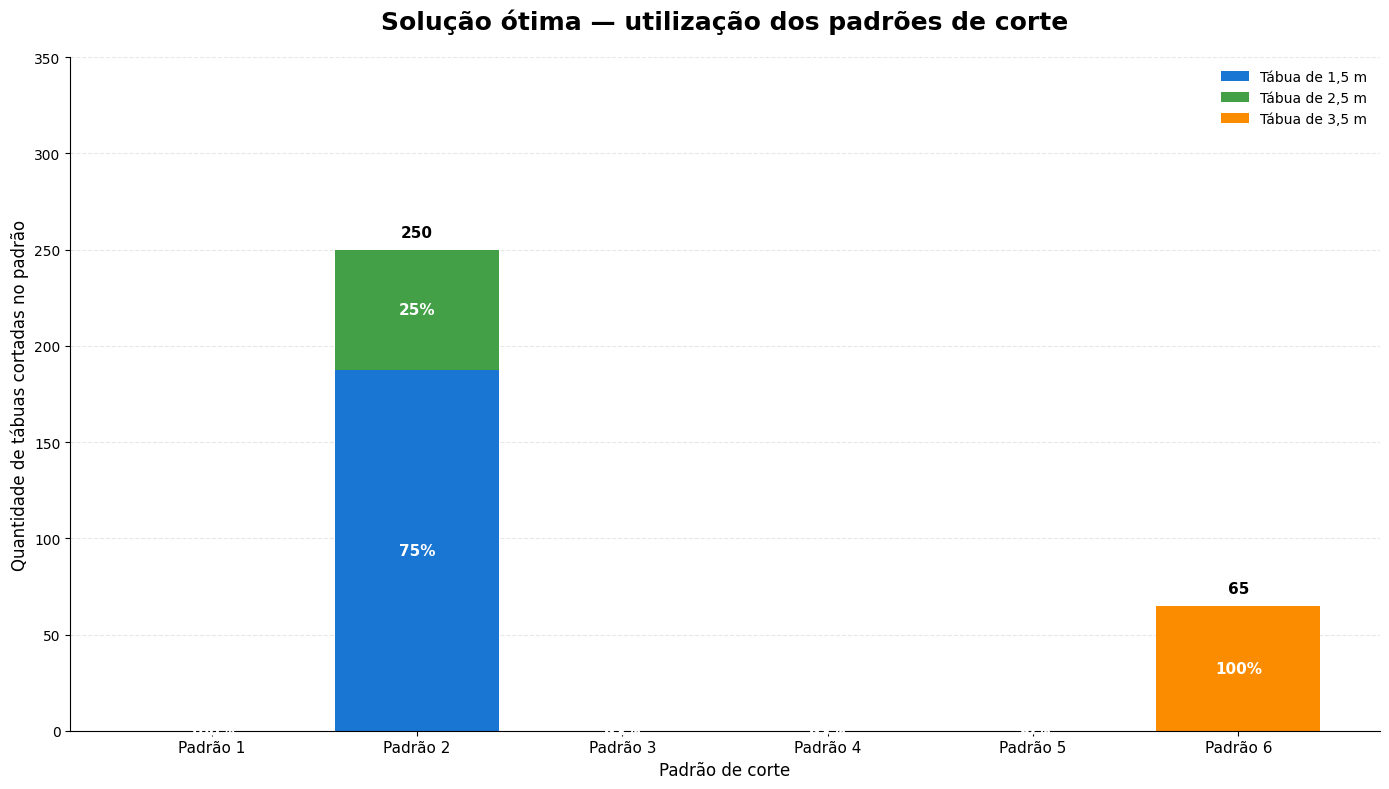

In [6]:
grafico_padroes_corte(
    modelo,
    codigo_cmpl
)

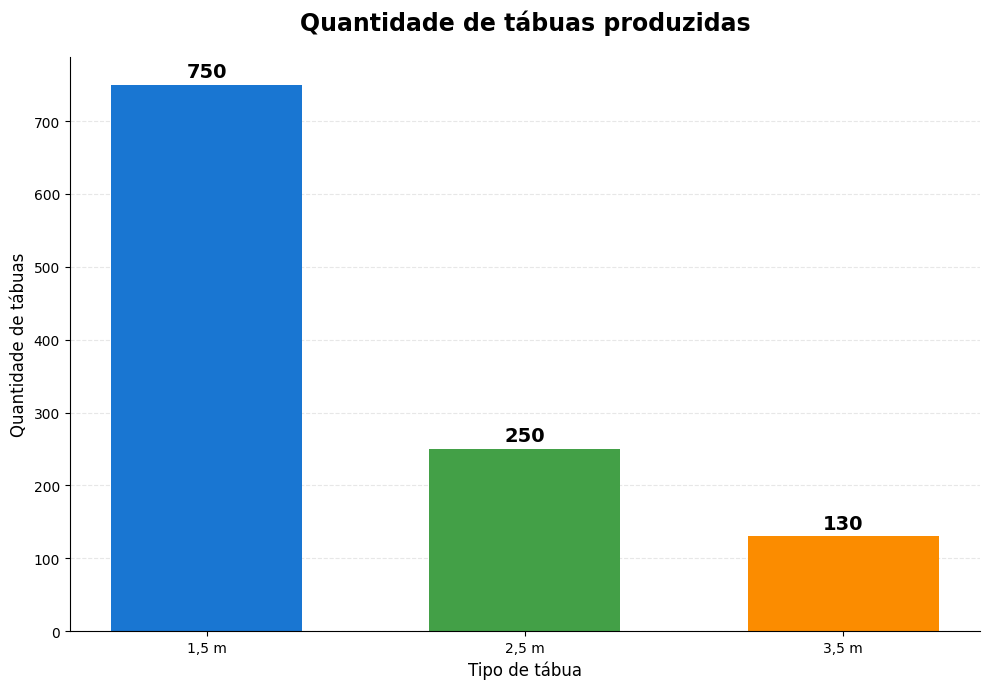

In [7]:
grafico_tabuas_atendidas(modelo)

# Source code

The source code is available on Github:
Cmpl official realeases: https://github.com/coin-or/Cmpl

Cmpl working git: https://github.com/MikeSteglich/Cmpl2

Coliop: https://github.com/MikeSteglich/Coliop

pyCmpl: https://github.com/MikeSteglich/pyCmpl3